In [4]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
root_dir = "/content/drive/My Drive/"
project_folder = "lncAPNet/CLL"
os.chdir(root_dir + project_folder)
!pwd

Mounted at /content/drive
/content/drive/My Drive/lncAPNet/CLL


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [5]:
df = pd.read_excel('Post-hoc_analyses/Outputs/NetBID2_res/ICGC_NetBID2_ms_tab.xlsx')

In [7]:
# Split based on funcType
df_NC = df[df['funcType'] == 'NC']
df_SIG = df[df['funcType'] == 'SIG']
df_TF = df[df['funcType'] == 'TF']

# Optional: check their sizes
print("NC shape:", df_NC.shape)
print("SIG shape:", df_SIG.shape)
print("TF shape:", df_TF.shape)

NC shape: (5230, 31)
SIG shape: (7132, 31)
TF shape: (1617, 31)


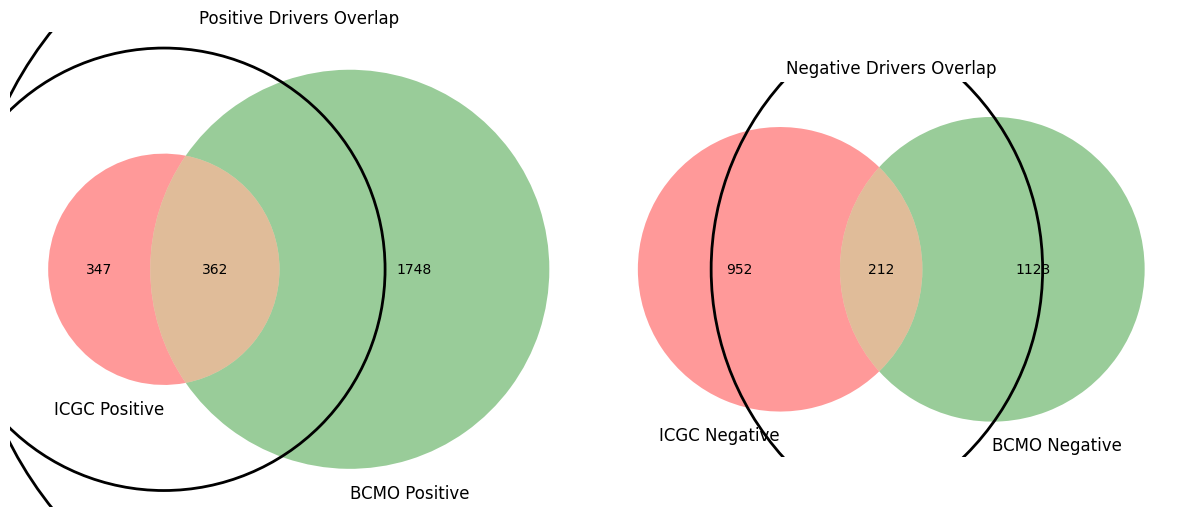

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

# Load the Excel files
icgc = pd.read_excel('Post-hoc_analyses/Outputs/NetBID2_res/ICGC_NetBID2_ms_tab.xlsx')
bcmo = pd.read_excel('Post-hoc_analyses/Outputs/NetBID2_res/BCMO_NetBID2_ms_tab.xlsx')

# Filter for positive drivers
icgc_pos = icgc[(icgc["adj.P.Val.U.Vs.M_DA"] < 0.05) & (icgc["logFC.U.Vs.M_DA"] > 0) & (icgc["Size"] > 30)]
bcmo_pos = bcmo[(bcmo["adj.P.Val.U.Vs.M_DA"] < 0.05) & (bcmo["logFC.U.Vs.M_DA"] > 0) & (bcmo["Size"] > 30)]

# Filter for negative drivers
icgc_neg = icgc[(icgc["adj.P.Val.U.Vs.M_DA"] < 0.05) & (icgc["logFC.U.Vs.M_DA"] < 0) & (icgc["Size"] > 30)]
bcmo_neg = bcmo[(bcmo["adj.P.Val.U.Vs.M_DA"] < 0.05) & (bcmo["logFC.U.Vs.M_DA"] < 0) & (bcmo["Size"] > 30)]

# Create sets of originalID
set_icgc_pos = set(icgc_pos['originalID'].dropna())
set_bcmo_pos = set(bcmo_pos['originalID'].dropna())

set_icgc_neg = set(icgc_neg['originalID'].dropna())
set_bcmo_neg = set(bcmo_neg['originalID'].dropna())

# Calculate union sizes to fix circle sizes (max size across all sets)
all_sets = [set_icgc_pos, set_bcmo_pos, set_icgc_neg, set_bcmo_neg]
max_size = max(len(s) for s in all_sets)

# Function to plot venn with fixed circle sizes
def venn_fixed(ax, set1, set2, label1, label2, title):
    v = venn2([set1, set2], set_labels=(label1, label2), ax=ax)
    c = venn2_circles([set1, set2], ax=ax)

    # Fix circle sizes by scaling radii based on max_size
    for i, circle in enumerate(c):
        radius = (len([set1, set2][i]) / max_size)**0.5
        circle.set_radius(radius)
        circle.set_lw(2)
    ax.set_title(title)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

venn_fixed(axes[0], set_icgc_pos, set_bcmo_pos, 'ICGC Positive', 'BCMO Positive', 'Positive Drivers Overlap')
venn_fixed(axes[1], set_icgc_neg, set_bcmo_neg, 'ICGC Negative', 'BCMO Negative', 'Negative Drivers Overlap')

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# Load the Excel file
df_icgc = pd.read_excel('Post-hoc_analyses/Outputs/NetBID2_res/ICGC_NetBID2_ms_tab.xlsx')

# ---- Hidden group filters ----
hidden_df_icgc = df_icgc[
    (df_icgc['adj.P.Val.U.Vs.M_DE'] > 0.05) &
    (df_icgc['adj.P.Val.U.Vs.M_DA'] < 0.05)
]

# ---- Overt group filters ----
overt_df_icgc = df_icgc[
    (df_icgc['adj.P.Val.U.Vs.M_DE'] < 0.05) &
    (df_icgc['adj.P.Val.U.Vs.M_DA'] < 0.05)
]

# ---- Split hidden by funcType ----
hidden_NC_icgc = hidden_df_icgc[hidden_df_icgc['funcType'] == 'NC']
hidden_SIG_icgc = hidden_df_icgc[hidden_df_icgc['funcType'] == 'SIG']
hidden_TF_icgc = hidden_df_icgc[hidden_df_icgc['funcType'] == 'TF']

# ---- Split overt by funcType ----
overt_NC_icgc = overt_df_icgc[overt_df_icgc['funcType'] == 'NC']
overt_SIG_icgc = overt_df_icgc[overt_df_icgc['funcType'] == 'SIG']
overt_TF_icgc = overt_df_icgc[overt_df_icgc['funcType'] == 'TF']

# ---- Optional: Check how many in each ----
print("Hidden NC:", hidden_NC_icgc.shape)
print("Hidden SIG:", hidden_SIG_icgc.shape)
print("Hidden TF:", hidden_TF_icgc.shape)

print("Overt NC:", overt_NC_icgc.shape)
print("Overt SIG:", overt_SIG_icgc.shape)
print("Overt TF:", overt_TF_icgc.shape)


Hidden NC: (1324, 31)
Hidden SIG: (1590, 31)
Hidden TF: (388, 31)
Overt NC: (564, 31)
Overt SIG: (1145, 31)
Overt TF: (253, 31)


In [13]:
import pandas as pd

# Load the Excel file for BCMO
df_bcmo = pd.read_excel('Post-hoc_analyses/Outputs/NetBID2_res/BCMO_NetBID2_ms_tab.xlsx')

# ---- Hidden group filters ----
hidden_df_bcmo = df_bcmo[
    (df_bcmo['adj.P.Val.U.Vs.M_DE'] > 0.05) &
    (df_bcmo['adj.P.Val.U.Vs.M_DA'] < 0.05)
]

# ---- Overt group filters ----
overt_df_bcmo = df_bcmo[
    (df_bcmo['adj.P.Val.U.Vs.M_DE'] < 0.05) &
    (df_bcmo['adj.P.Val.U.Vs.M_DA'] < 0.05)
]

# ---- Split hidden by funcType ----
hidden_NC_bcmo = hidden_df_bcmo[hidden_df_bcmo['funcType'] == 'NC']
hidden_SIG_bcmo = hidden_df_bcmo[hidden_df_bcmo['funcType'] == 'SIG']
hidden_TF_bcmo = hidden_df_bcmo[hidden_df_bcmo['funcType'] == 'TF']

# ---- Split overt by funcType ----
overt_NC_bcmo = overt_df_bcmo[overt_df_bcmo['funcType'] == 'NC']
overt_SIG_bcmo = overt_df_bcmo[overt_df_bcmo['funcType'] == 'SIG']
overt_TF_bcmo = overt_df_bcmo[overt_df_bcmo['funcType'] == 'TF']

# ---- Optional: Check how many in each ----
print("BCMO Hidden NC:", hidden_NC_bcmo.shape)
print("BCMO Hidden SIG:", hidden_SIG_bcmo.shape)
print("BCMO Hidden TF:", hidden_TF_bcmo.shape)

print("BCMO Overt NC:", overt_NC_bcmo.shape)
print("BCMO Overt SIG:", overt_SIG_bcmo.shape)
print("BCMO Overt TF:", overt_TF_bcmo.shape)


BCMO Hidden NC: (955, 31)
BCMO Hidden SIG: (1595, 31)
BCMO Hidden TF: (356, 31)
BCMO Overt NC: (372, 31)
BCMO Overt SIG: (783, 31)
BCMO Overt TF: (161, 31)


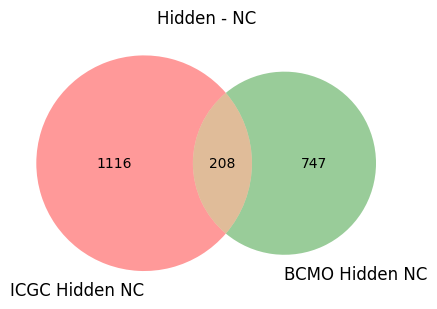

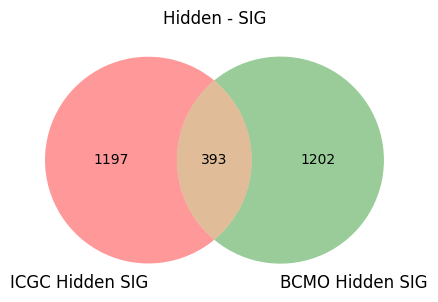

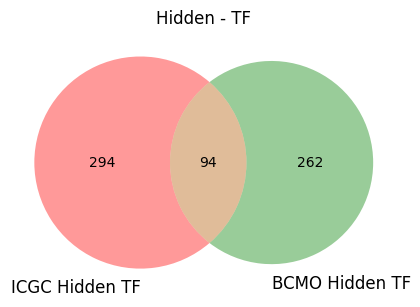

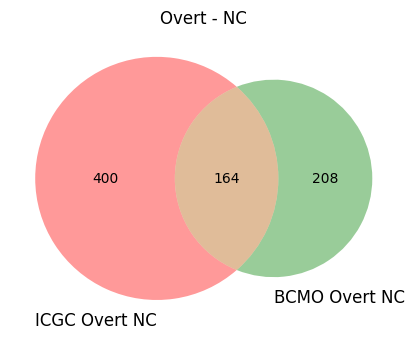

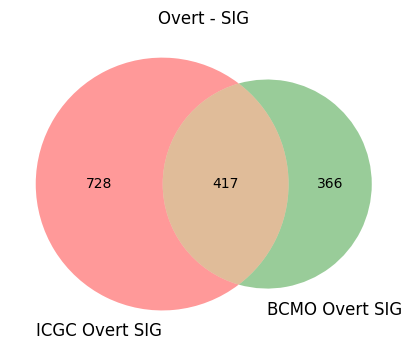

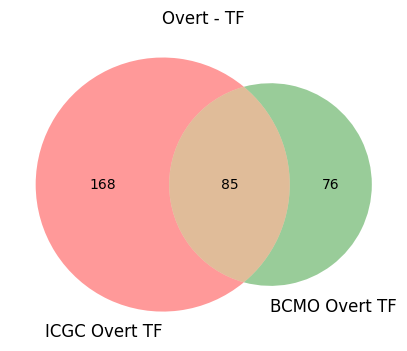

In [14]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Function to plot Venn diagrams
def plot_venn(set1, set2, label1, label2, title):
    plt.figure(figsize=(5, 5))
    venn2([set1, set2], set_labels=(label1, label2))
    plt.title(title)
    plt.show()

# Choose column to compare (e.g., geneSymbol)
column = 'geneSymbol'

# Hidden comparisons
plot_venn(
    set(hidden_NC_icgc[column].dropna()),
    set(hidden_NC_bcmo[column].dropna()),
    'ICGC Hidden NC',
    'BCMO Hidden NC',
    'Hidden - NC'
)

plot_venn(
    set(hidden_SIG_icgc[column].dropna()),
    set(hidden_SIG_bcmo[column].dropna()),
    'ICGC Hidden SIG',
    'BCMO Hidden SIG',
    'Hidden - SIG'
)

plot_venn(
    set(hidden_TF_icgc[column].dropna()),
    set(hidden_TF_bcmo[column].dropna()),
    'ICGC Hidden TF',
    'BCMO Hidden TF',
    'Hidden - TF'
)

# Overt comparisons
plot_venn(
    set(overt_NC_icgc[column].dropna()),
    set(overt_NC_bcmo[column].dropna()),
    'ICGC Overt NC',
    'BCMO Overt NC',
    'Overt - NC'
)

plot_venn(
    set(overt_SIG_icgc[column].dropna()),
    set(overt_SIG_bcmo[column].dropna()),
    'ICGC Overt SIG',
    'BCMO Overt SIG',
    'Overt - SIG'
)

plot_venn(
    set(overt_TF_icgc[column].dropna()),
    set(overt_TF_bcmo[column].dropna()),
    'ICGC Overt TF',
    'BCMO Overt TF',
    'Overt - TF'
)
